saved G2D2_Agwb.png/.pdf


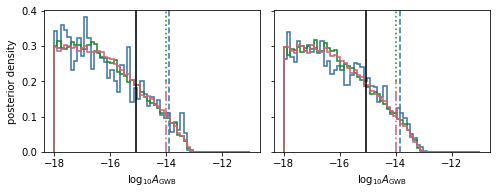

In [5]:
# =====================================================================
# SGWB subsection figure (Test iv): log10 A_GWB posteriors for the six
# CW+GWB detection runs, two panels (broad | fixed), three softwares.
# Broken vertical lines: 95th percentile per software. Enterprise and
# QuickCW-dL coincide to 0.01 dex, so they are drawn over the upper and
# lower panel halves to keep both visible. Black line: injection.
# =====================================================================
import numpy as np
import h5py
import matplotlib.pyplot as plt

np.random.seed(42)
ENT_BURN = 3000
T_AMP = -15.070581074285707   # injected log10 A_GWB (MDC2 JSON)
C_QCW, C_ENT, C_DL = "#4477AA", "#228833", "#CC6677"
LW = 1.6

FILES = {
    "broad": dict(
        qcw="/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_broad_detect_tref_09_Jun_2026_dLmasked_75.400Mpc.h5",
        loki="/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_broad_detect_loki_100M_lastTOA_02_Jun_2026.h5",
        ent="/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_varyfgw_core_new.h5"),
    "fixed": dict(
        qcw="/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_narrow_detect_tref_09_Jun_2026_dLmasked_75.400Mpc.h5",
        loki="/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_fixed_detect_loki_100M_lastTOA_02_Jun_2026.h5",
        ent="/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_core_fixed_new.h5"),
}

def get_amp(path, dset, names_key, col, burn=None, loki=False):
    with h5py.File(path, "r") as f:
        pn = [p.decode() if isinstance(p, bytes) else p for p in f[names_key][:]]
        j = pn.index(col)
        if loki:
            a = f[dset][0, :, j]
        else:
            a = f[dset][:, j]
    return a[burn:] if burn else a

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8), sharey=True)
bins = np.linspace(-18.0, -11.0, 60)
for ax, cfg in zip(axes, ("broad", "fixed")):
    fp = FILES[cfg]
    qcw  = get_amp(fp["qcw"],  "samples_masked", "par_names", "gwb_log10_A")
    loki = get_amp(fp["loki"], "samples_cold",   "par_names", "gwb_log10_A", loki=True)
    ent  = get_amp(fp["ent"],  "chain",          "params",    "crn_log10_A", burn=ENT_BURN)
    for a, c, ls, y0, y1 in ((qcw,  C_QCW, "--", 0.0, 1.0),
                             (ent,  C_ENT, ":",  0.5, 1.0),
                             (loki, C_DL,  "-.", 0.0, 0.5)):
        ax.hist(a, bins=bins, density=True, histtype="step", color=c, lw=LW)
        ax.axvline(np.percentile(a, 95), color=c, lw=1.6, ls=ls, ymin=y0, ymax=y1)
    ax.axvline(T_AMP, color="k", lw=LW)
    ax.set_xlabel(r"$\log_{10} A_{\rm GWB}$")
axes[0].set_ylabel("posterior density")
plt.tight_layout()
fig.savefig("G2D2_Agwb.png", dpi=300, bbox_inches="tight")
fig.savefig("G2D2_Agwb.pdf", bbox_inches="tight")
print("saved G2D2_Agwb.png/.pdf")

saved G2D2_Agwb.png/.pdf


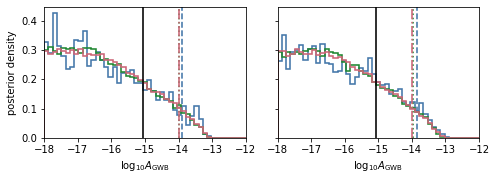

In [8]:
# ===== FINAL: log10 A_GWB posteriors, six CW+GWB detection runs =====
import numpy as np
import h5py
import matplotlib.pyplot as plt

ENT_BURN = 3000
T_AMP = -15.070581074285707
C_QCW, C_ENT, C_DL = "#4477AA", "#228833", "#CC6677"
LW = 1.6

FILES = {
    "broad": dict(
        qcw="/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_broad_detect_tref_09_Jun_2026_dLmasked_75.400Mpc.h5",
        loki="/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_broad_detect_loki_100M_lastTOA_02_Jun_2026.h5",
        ent="/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_varyfgw_core_new.h5"),
    "fixed": dict(
        qcw="/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_narrow_detect_tref_09_Jun_2026_dLmasked_75.400Mpc.h5",
        loki="/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_fixed_detect_loki_100M_lastTOA_02_Jun_2026.h5",
        ent="/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_core_fixed_new.h5"),
}

def get_amp(path, dset, names_key, col, burn=None, lk=False):
    with h5py.File(path, "r") as f:
        pn = [p.decode() if isinstance(p, bytes) else p for p in f[names_key][:]]
        j = pn.index(col)
        a = f[dset][0, :, j] if lk else f[dset][:, j]
    return a[burn:] if burn else a

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6), sharey=True)
bins = np.linspace(-18.0, -12.0, 48)
for ax, cfg in zip(axes, ("broad", "fixed")):
    fp = FILES[cfg]
    qcw  = get_amp(fp["qcw"],  "samples_masked", "par_names", "gwb_log10_A")
    loki = get_amp(fp["loki"], "samples_cold",   "par_names", "gwb_log10_A", lk=True)
    ent  = get_amp(fp["ent"],  "chain",          "params",    "crn_log10_A", burn=ENT_BURN)
    for a, c, ls in ((qcw, C_QCW, "--"), (ent, C_ENT, ":"), (loki, C_DL, "-.")):
        p95 = np.percentile(a, 95)
        ax.hist(a, bins=bins, density=True, histtype="step", color=c, lw=LW)
        ax.axvline(p95, color=c, lw=1.6, ls=ls)
    ax.axvline(T_AMP, color="k", lw=LW)
    ax.set_xlim(-18.0, -12.0)
    ax.set_xlabel(r"$\log_{10} A_{\rm GWB}$")
axes[0].set_ylabel("posterior density")
plt.tight_layout()
fig.savefig("G2D2_Agwb.png", dpi=300, bbox_inches="tight")
fig.savefig("G2D2_Agwb.pdf", bbox_inches="tight")
print("saved G2D2_Agwb.png/.pdf")


saved stacked G2D2_Agwb


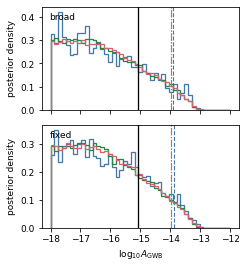

In [9]:
# ===== FINAL stacked, true column size =====
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 9})
fig, axes = plt.subplots(2, 1, figsize=(3.5, 3.8), sharex=True)
bins = np.linspace(-18.0, -12.0, 48)
for ax, cfg in zip(axes, ("broad", "fixed")):
    fp = FILES[cfg]
    qcw  = get_amp(fp["qcw"], "samples_masked", "par_names", "gwb_log10_A")
    loki = get_amp(fp["loki"], "samples_cold", "par_names", "gwb_log10_A", lk=True)
    ent  = get_amp(fp["ent"], "chain", "params", "crn_log10_A", burn=ENT_BURN)
    for a, c, ls in ((qcw, C_QCW, "--"), (ent, C_ENT, ":"), (loki, C_DL, "-.")):
        ax.hist(a, bins=bins, density=True, histtype="step", color=c, lw=1.3)
        ax.axvline(np.percentile(a, 95), color=c, lw=1.1, ls=ls)
    ax.axvline(T_AMP, color="k", lw=1.3)
    ax.set_ylabel("posterior density")
axes[1].set_xlabel(r"$\log_{10} A_{\rm GWB}$")
axes[0].text(0.04, 0.88, "broad", transform=axes[0].transAxes)
axes[1].text(0.04, 0.88, "fixed", transform=axes[1].transAxes)
plt.tight_layout()
fig.savefig("G2D2_Agwb.png", dpi=300, bbox_inches="tight")
fig.savefig("G2D2_Agwb.pdf", bbox_inches="tight")
print("saved stacked G2D2_Agwb")
